# **[1] CNN 기초**

## **CNN(합성곱신경망)**
* Convolution Neural Network (=행렬내적)
* 필터(커널)를 사용해 입력된 이미지에서 특징을 추출하는 기법
* 이미지 전체 X 부분을 보는 것이 핵심 아이디어
* 특징 추출 후 fully connected layers로 한줄로 피고 학습

## **Convolution layer(컨볼루션레이어) : 합성곱**
* 입력 데이터로부터 특징을 추출하는 기법 >>> 피쳐맵
* 피쳐가 여러개면 : 필터 * 피쳐 >> 피쳐 개수만큼 피쳐맵이 만들어짐

## **Stride(스트라이드)**
* 필터 적용을 위한 간격 (몇칸씩 이동할건지)
* Stride1 = 한칸씩 이동
* 크게 하면 출력(피쳐맵)이 작아짐

## **Padding(패딩)**
* 입력 데이터 주변 잘리는 부분을 빈공간으로 채워 인식하는 것
* Padding1 = 한칸씩 한바퀴
* 입력데이터 모양을 유지한채로 다음 계층에 전달하기 위함
* 크게하면 출력(피쳐맵)이 커짐

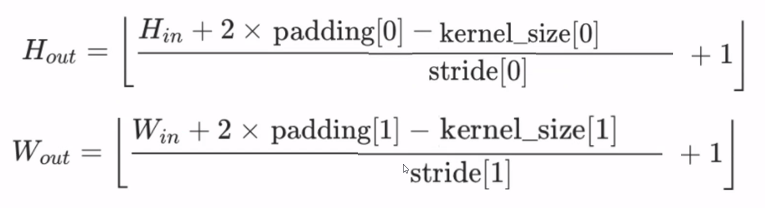

<pre>
** 4*4 원본 사진에 2*2필터, 패딩1, 스트라이드1 조건으로 출력되는 피쳐맵의 크기는??
= 피쳐맵 = 5*5

** 4*4, 필터 3*3, 패딩1, 스트라이드1
= 4 + 2 * 1 - 3 +1
= 4*4

** 7*7, 필터 3*3, 패딩0, 스트라이드1
= 7 + 2 * 0 - 3 +1
= 5*5

** 28*31, 필터 5*5, 패딩2, 스트라이드3
= ( 3 / 28 + 2 * 2 - 5 ) +1
= ( 3 / 31 + 2 * 2 - 5 ) +1
= 10, 11

## **Pooling(풀링)**
* 추출된 Activation map을 인위로 줄이는 작업
* Max pooling : 연한녹색/찐녹색/그냥녹색 -----> 찐녹색 1개만
  * 기본은 반값 (4* 4 => 2*2)
* Average pooling : 연녹1/찐녹8/그냥녹3 ------> 평균값 4로 

---------------------------------

# **[실습1] CNN모델**

In [3]:
from sklearn import set_config
set_config(display="text")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split                   #문제/답 분리

import tensorflow as tf
tf.random.set_seed(1234)
np.random.seed(1234)

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D    #-----CNN
from keras.layers import Dense, Flatten          #-----FC

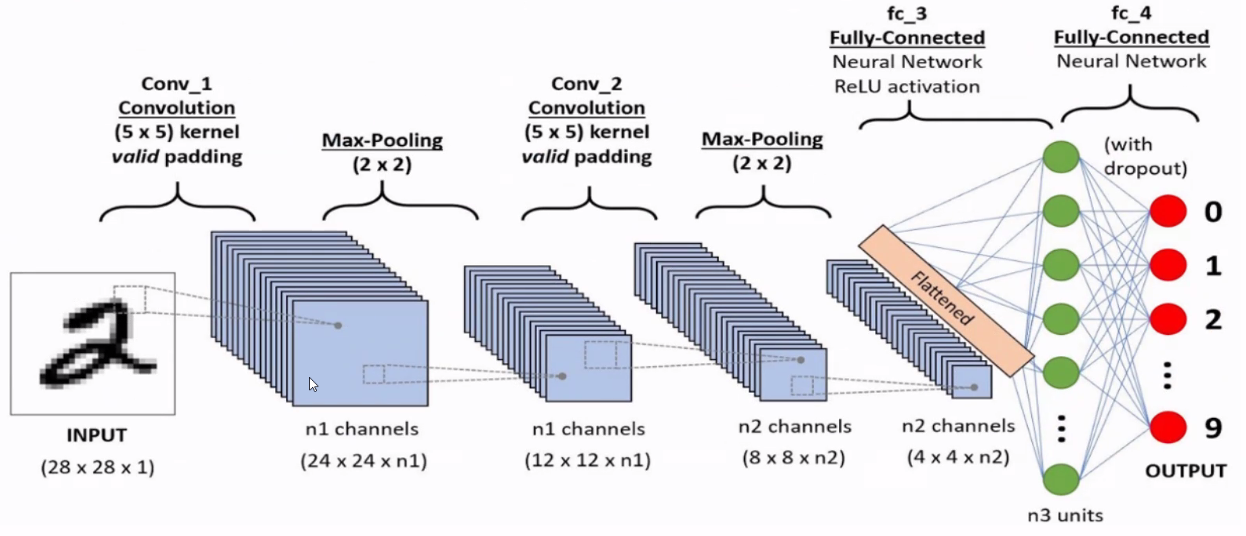

> 필터 : 16, 16, 24, 24

In [7]:
#Conv2D?
#MaxPooling2D?

In [13]:
from keras.datasets.fashion_mnist import load_data

In [14]:
(X_train, y_train), (X_test, y_test) = load_data()

In [15]:
model = Sequential([
    Conv2D(filters=16, kernel_size=(5, 5), strides=(1, 1), padding='valid', activation='relu', input_shape=(28,28,1)),    # --------- stride&padding : 지정값 없으면 기본값
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(filters=24, kernel_size=(5, 5), strides=(1, 1), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(units=60, activation='relu'),
    Dense(units=20, activation='relu'),             # --------- 2개 : 그림에 없는 히든 레이어 
    Dense(units=10, activation='softmax')
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

In [16]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 24, 24, 16)          │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 12, 12, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 8, 8, 24)            │           9,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 4, 4, 24)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 384)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 60)                  │          23,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 20)                  │           1,220 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 10)                  │             210 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,570 (135.04 KB)

 Trainable params: 34,570 (135.04 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
fit_res = model.fit( X_train, y_train, batch_size=256, epochs=40, validation_data=(X_test, y_test) )

Epoch 1/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9262 - loss: 0.1960 - val_accuracy: 0.8867 - val_loss: 0.3688
Epoch 2/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9272 - loss: 0.1944 - val_accuracy: 0.8853 - val_loss: 0.3781
Epoch 3/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9282 - loss: 0.1899 - val_accuracy: 0.8829 - val_loss: 0.3975
Epoch 4/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9284 - loss: 0.1903 - val_accuracy: 0.8844 - val_loss: 0.3943
Epoch 5/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9319 - loss: 0.1815 - val_accuracy: 0.8870 - val_loss: 0.3893
Epoch 6/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9329 - loss: 0.1803 - val_accuracy: 0.8832 - val_loss: 0.4072
Epoch 7/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9345 - loss: 0.1762 - val_accuracy: 0.8867 - val_loss: 0.4119
Epoch 8/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9390 - loss: 0.1653 - val_accuracy: 0.

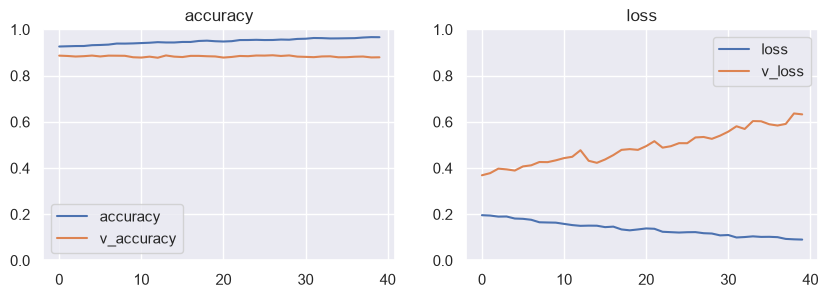

In [23]:
plt.figure(figsize=(10,3))
ax1 = plt.subplot(1,2,1)
ax1.plot(fit_res.history['accuracy'], label="accuracy")
ax1.plot(fit_res.history['val_accuracy'], label="v_accuracy")
ax1.legend()
ax1.set_ylim(0, 1)
ax1.set_title("accuracy")

ax2 = plt.subplot(1,2,2)
ax2.plot(fit_res.history['loss'], label="loss")
ax2.plot(fit_res.history['val_loss'], label="v_loss")
ax2.legend()
ax2.set_ylim(0, 1)
ax2.set_title("loss")

plt.show()

In [20]:
res = model.evaluate(X_test, y_test)
print( f"accuracy : {res[1]:.4f}" )

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8795 - loss: 0.6325
accuracy : 0.8795


# **[실습2] CNN모델**

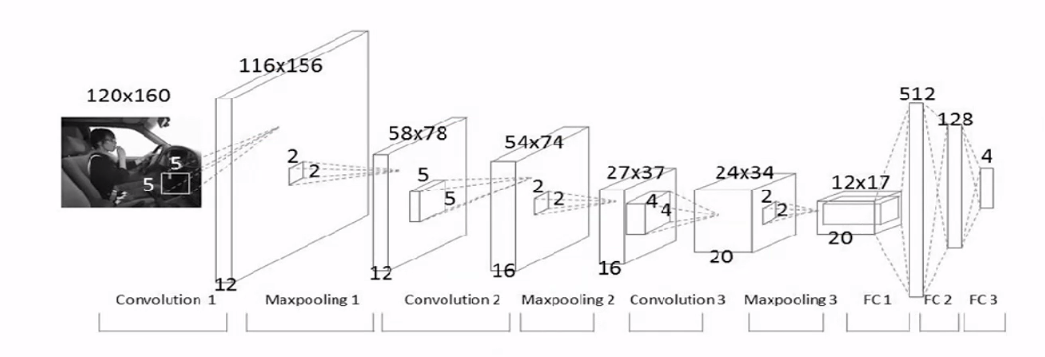

In [24]:
model = Sequential([
    Conv2D(filters=12, kernel_size=(5, 5), strides=(1, 1), padding='valid', activation='relu', input_shape=(120, 160, 1)),    # --------- RGB = 흑백은 1, 컬러는 3
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(filters=16, kernel_size=(5, 5), strides=(1, 1), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(filters=20, kernel_size=(4, 4), strides=(1, 1), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(units=512, activation='relu'),
    Dense(units=128, activation='relu'),
    Dense(units=4, activation='softmax')             # --------- 히든 레이어 : 그림대로 아웃풋 unit 값 지정
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

In [25]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 116, 156, 12)        │             312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 58, 78, 12)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 54, 74, 16)          │           4,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 27, 37, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 24, 34, 20)          │           5,140 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 12, 17, 20)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 4080)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 512)                 │       2,089,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,165,920 (8.26 MB)

 Trainable params: 2,165,920 (8.26 MB)

 Non-trainable params: 0 (0.00 B)